In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [1]:
S1_T0 = [[7,2,1,0,0], [2,6,1,0,1], [0,3,7,0,0], [0,0,0,9,1], [0,0,0,3,7]]
S1_T1 = [[8,1,1,0,0], [1,9,0,0,0], [1,1,8,0,0], [0,0,0,10,0], [0,0,0,2,8]]
S1_T2 = [[9,1,0,0,0], [1,9,0,0,0], [0,1,9,0,0], [0,0,0,10,0], [0,0,0,1,9]]
S1_T3 = [[10,0,0,0,0], [0,10,0,0,0], [0,1,9,0,0], [0,0,0,10,0], [0,0,0,0,10]]

S2_T0 = [[6,2,2,0,0], [3,5,2,0,0], [0,1,9,0,0], [0,0,0,10,0], [0,0,1,1,8]]
S2_T1 = [[7,2,1,0,0], [0,7,2,0,1], [0,1,8,0,1], [0,0,0,10,0], [0,0,0,1,9]]
S2_T2 = [[9,0,1,0,0], [0,9,1,0,0], [0,0,9,0,1], [0,0,0,10,0], [0,0,0,1,9]]
S2_T3 = [[10,0,0,0,0], [0,9,1,0,0], [0,1,9,0,0], [0,0,0,10,0], [0,0,0,0,10]]

S3_T0 = [[7,3,0,0,0], [1,7,2,0,0], [0,0,4,6,0], [0,0,0,0,10], [0,1,2,1,6]]
S3_T1 = [[8,2,0,0,0], [0,8,1,0,1], [0,3,7,0,0], [0,0,0,10,0], [0,0,0,3,7]]
S3_T2 = [[10,0,0,0,0], [0,7,3,0,0], [0,2,8,0,0], [0,0,0,10,0], [0,0,0,0,10]]
S3_T3 = [[10,0,0,0,0], [0,9,1,0,0], [0,2,8,0,0], [0,0,0,10,0], [0,0,0,0,10]]

In [3]:
plt.rcParams["font.family"] = "Times New Roman"

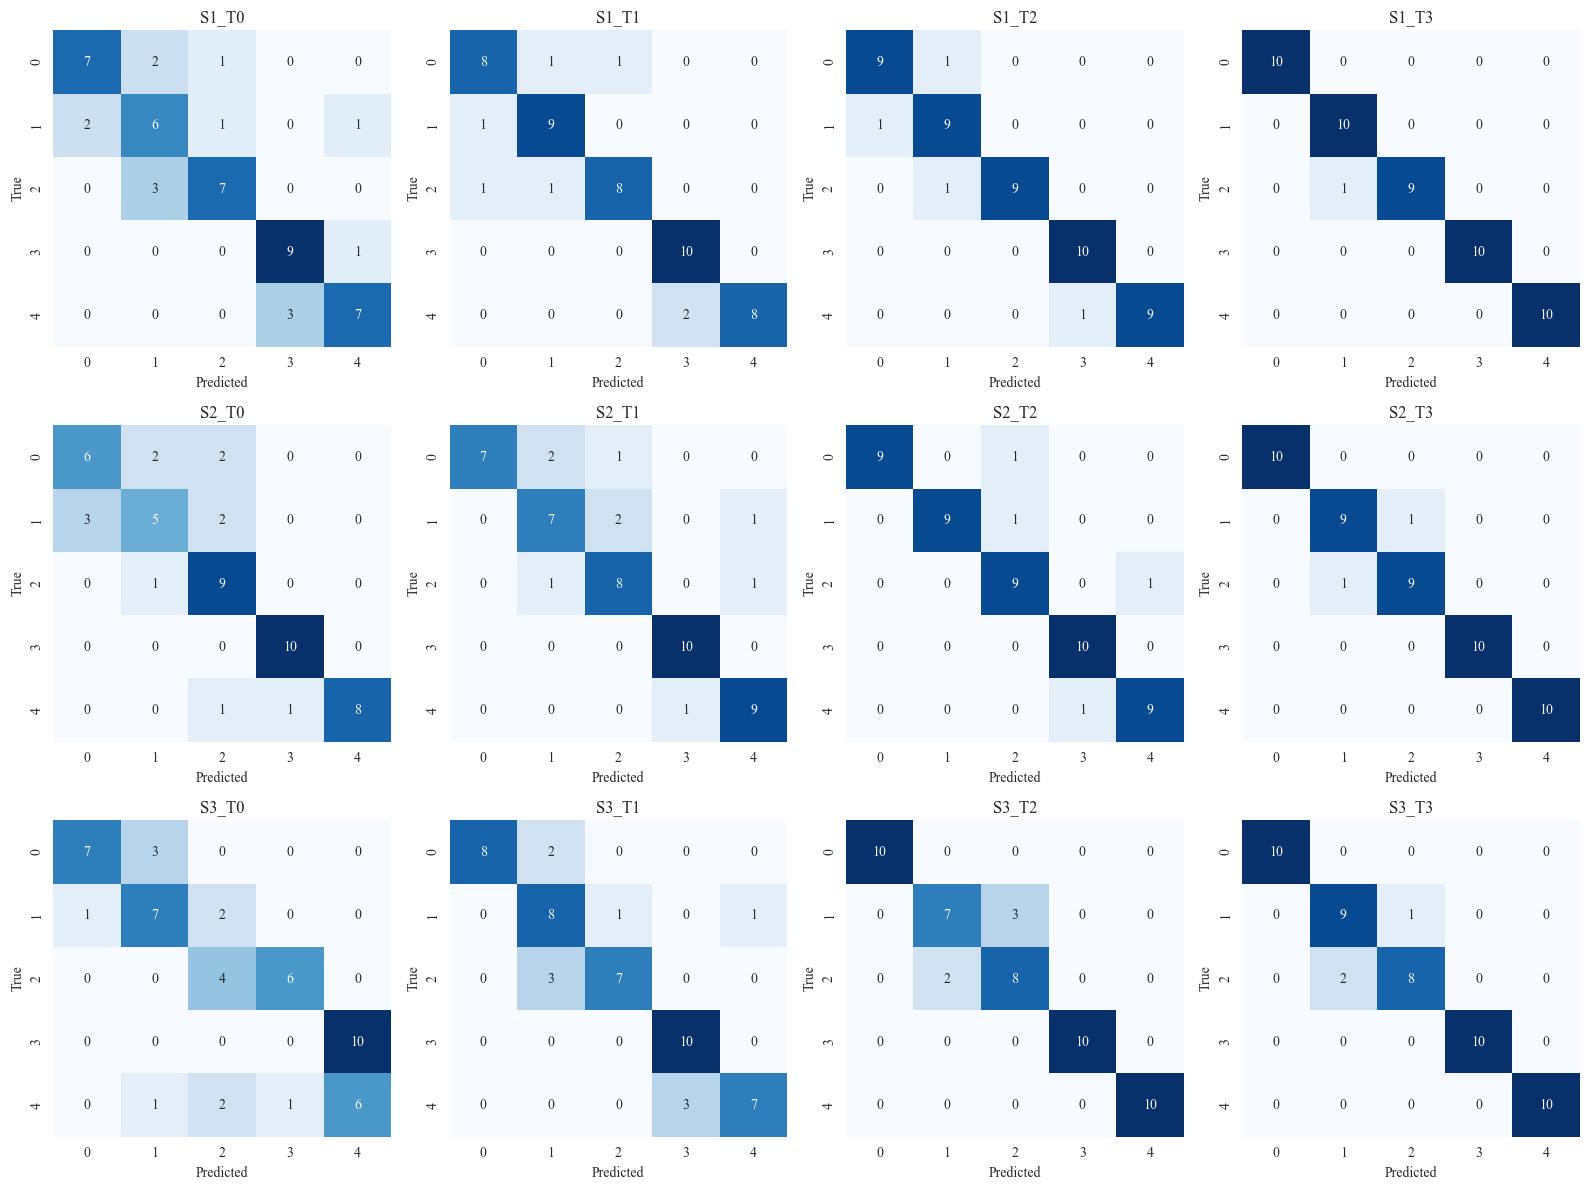

In [7]:
data = {
    "S1": [S1_T0, S1_T1, S1_T2, S1_T3],
    "S2": [S2_T0, S2_T1, S2_T2, S2_T3],
    "S3": [S3_T0, S3_T1, S3_T2, S3_T3],
}

fig, axes = plt.subplots(len(data), 4, figsize=(16, 12))

for i, (subject, matrices) in enumerate(data.items()):
    for j, mat in enumerate(matrices):
        ax = axes[i, j]
        sns.heatmap(np.array(mat), annot=True, fmt="d", cmap="Blues",
                    cbar=False, ax=ax,
                    annot_kws={"fontsize": 10})
        ax.set_title(f"{subject}_T{j}", fontsize=12)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")

plt.tight_layout()
plt.show()

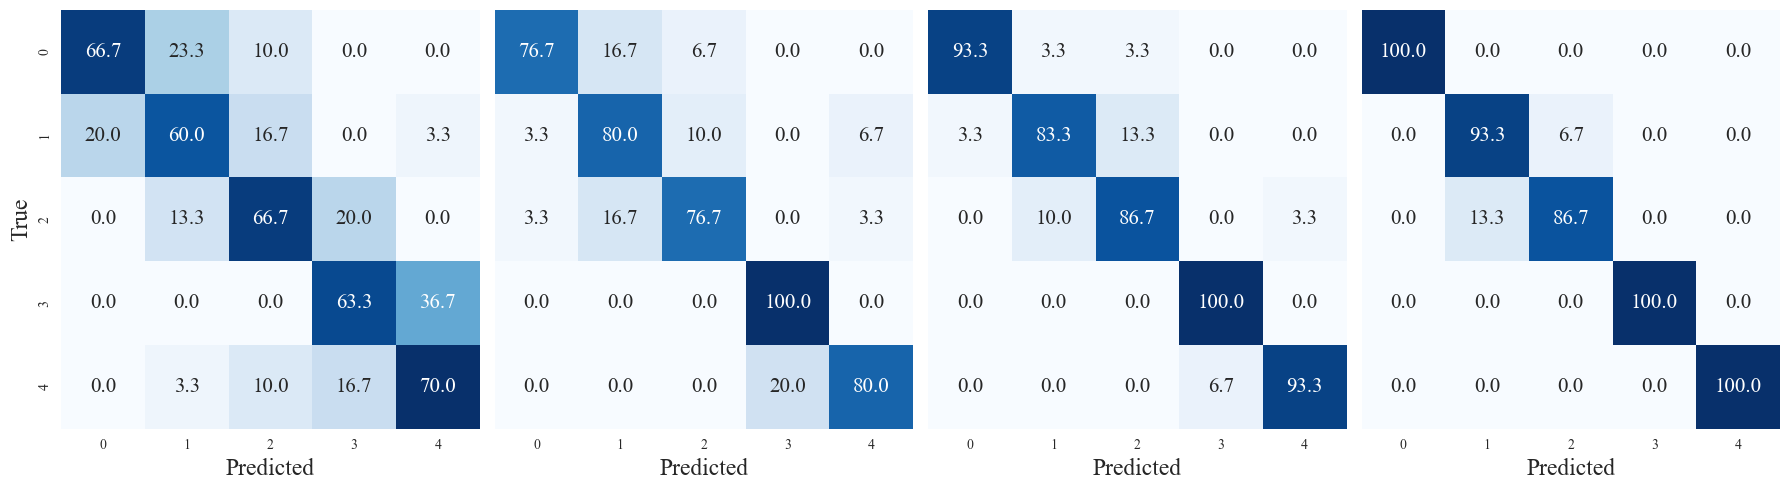

In [23]:
avg_matrices = []
for t in range(4):  # T0–T3
    mats = [np.array(data[subj][t]) for subj in data]
    avg_mat = np.mean(mats, axis=0)
    avg_matrices.append(avg_mat)

# Function: normalize row-wise to percentages
def row_normalize(mat):
    mat = np.array(mat)
    row_sums = mat.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1  # avoid div by zero
    return mat / row_sums * 100

# Plot four averaged heatmaps
fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharex=True, sharey=True)

for t, mat in enumerate(avg_matrices):
    ax = axes[t]
    perc_mat = row_normalize(mat)
    sns.heatmap(
        perc_mat, annot=True, fmt=".1f", cmap="Blues",
        cbar=False, ax=ax, annot_kws={"fontsize": 15}
    )
    #ax.set_title(f"Averaged_T{t}", fontsize=20)
    ax.set_xlabel("Predicted", fontsize=17)
    if t==0:
        ax.set_ylabel("True", fontsize=17)

plt.tight_layout()
plt.show()

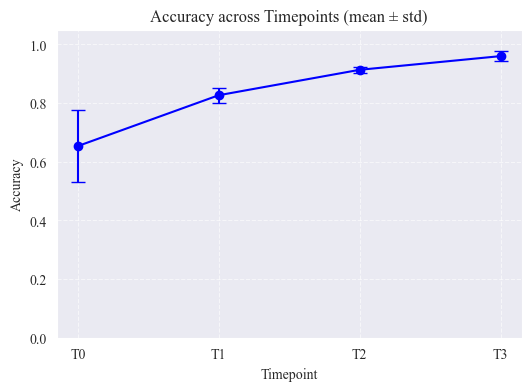

In [15]:
all_accuracies = []  # shape: [n_subjects, n_timepoints]
for subj in data:
    subj_acc = []
    for t in range(4):
        mat = np.array(data[subj][t])
        total = np.sum(mat)
        correct = np.trace(mat)
        acc = correct / total if total > 0 else 0
        subj_acc.append(acc)
    all_accuracies.append(subj_acc)

all_accuracies = np.array(all_accuracies)  # shape (3,4)

# ---- Mean and Std across subjects ----
mean_acc = np.mean(all_accuracies, axis=0)
std_acc = np.std(all_accuracies, axis=0)

# ---- Plot with error bars ----
plt.figure(figsize=(6,4))
plt.errorbar(
    range(4), mean_acc, yerr=std_acc,
    marker="o", linestyle="-", color="blue", capsize=5
)
plt.xticks(range(4), [f"T{i}" for i in range(4)])
plt.ylim(0, 1.05)
plt.ylabel("Accuracy")
plt.xlabel("Timepoint")
plt.title("Accuracy across Timepoints (mean ± std)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()